# Medidas de Concentración

Medidas que responden a *¿qué proporción del total se acumula en una fracción pequeña de las unidades de análisis?*:

- Curva de Lorenz
- Coeficiente de Gini

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
import polars as pl
from config.rutas import ARCHIVO_PROCESSED

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

## Paso 1: Carga de los Datos Limpios

Las medidas de concentración se calculan sobre el dataset ya limpio de la Práctica 3 (`data/data-processed/endireh_2021_clean.csv`), cuya ruta está en `config/rutas.py`.

Los nombres de las entidades vienen con un problema de codificación (p. ej. `NUEVO LEÃ\x93N`); `cargar_datos_limpios()` lo corrige **solo en memoria**, sin modificar el archivo.

In [4]:
from src.eda.carga import PESO, cargar_datos_limpios
from src.visualization import graficas

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(200)
pl.Config.set_float_precision(4)
%matplotlib inline

FIG_DIR = Path.cwd().parent / "figuras"   # carpeta de figuras en la raíz del proyecto
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(ARCHIVO_PROCESSED)
df = cargar_datos_limpios()
df.shape

/home/j_zarcoo/Documents/cc/unam/fc/opt/almacenes_mineria/lab/p3/eda/data/data-processed/endireh_2021_clean.csv


(105753, 25)

In [5]:
df.head()

cve_entidad,nom_entidad,cve_municipio,nom_municipio,edad_primer_union,num_hijos,nivel_escolaridad,estado_civil_id,estado_civil_desc,estrato_socioeconomico,pareja_trabaja_id,pareja_trabaja_desc,ingreso_pareja,dinero_propio_id,dinero_propio_desc,apoyo_gobierno_id,apoyo_gobierno_desc,tiene_ahorros_id,tiene_ahorros_desc,propietaria_vivienda_id,propietaria_vivienda_desc,sufrio_violencia_pareja,factor_expansion,anio_encuesta,nunca_tuvo_union
i64,str,i64,str,f64,f64,str,i64,str,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,bool
19,"""NUEVO LEÓN""",21,"""GENERAL ESCOBEDO""",null,4.0000,"""A1""",5,"""Casada""",1,1,1,200.0000,0,0,0,0,0,0,0,0,0,300,2021,true
12,"""GUERRERO""",57,"""TÉCPAN DE GALEANA""",null,1.0000,"""A1""",1,"""Unión libre""",1,0,0,null,1,1,0,0,0,0,1,1,0,231,2021,true
18,"""NAYARIT""",17,"""TEPIC""",null,1.0000,"""C1""",6,"""Soltera""",2,1,1,1000.0000,1,1,0,0,0,0,1,1,0,328,2021,true
1,"""AGUASCALIENTES""",5,"""JESÚS MARÍA""",null,4.0000,"""A1""",5,"""Casada""",2,1,1,400.0000,1,1,0,0,0,0,0,0,0,275,2021,true
16,"""MICHOACÁN DE OCAMPO""",19,"""COTIJA""",4.0000,3.0000,"""B1""",2,"""Separada""",1,1,1,700.0000,1,1,0,0,0,0,0,0,1,418,2021,false


In [6]:
print(f"Registros: {df.height:,} | Variables: {df.width} | Mujeres representadas (suma de {PESO}): {df[PESO].sum():,}")

Registros: 105,753 | Variables: 25 | Mujeres representadas (suma de factor_expansion): 49,144,970


## Paso 3: Medidas de Concentración – Curva de Lorenz y Coeficiente de Gini

Se analiza si los casos de violencia de pareja reportados, **ponderados por `factor_expansion`**, se concentran en pocas entidades federativas:

$$G = \frac{2\sum_{i=1}^{n} i\,x_{(i)} - (n+1)\sum_{i=1}^{n} x_{(i)}}{n\sum_{i=1}^{n} x_{(i)}}, \qquad x_{(i)} \text{ en orden ascendente}$$

$G = 0$: reparto homogéneo entre entidades; $G \to 1$: casi todos los casos en muy pocas entidades. Con $n = 32$ el valor máximo alcanzable es $(n-1)/n = 0.969$.

**Decisión de ponderación.** Un caso de la muestra representa a `factor_expansion` mujeres. Sin ponderar, cada entidad aporta ~3,300 entrevistas por diseño y el número de casos en la muestra refleja el diseño, no la población. Por eso los casos se suman como $\sum$ `factor_expansion` × `sufrio_violencia_pareja`. Además se calcula la población estimada de cada entidad para separar la concentración de casos del tamaño de cada entidad.

In [7]:
from src.eda.medidas_concentracion import tabla_por_entidad, tabla_gini, participacion_extremos

entidades = tabla_por_entidad(df)
with pl.Config(tbl_rows=-1):
    display(entidades.sort("casos", descending=True))

cve_entidad,nom_entidad,registros,casos_muestra,poblacion,casos,participacion_casos,participacion_poblacion
i64,str,u32,i64,i64,i64,f64,f64
15,"""MÉXICO""",3466,679,6879280,1333883,0.1521,0.1400
9,"""CIUDAD DE MÉXICO""",3241,556,4050571,699840,0.0798,0.0824
30,"""VERACRUZ DE IGNACIO DE LA LLAV…",3229,662,3203778,625007,0.0713,0.0652
14,"""JALISCO""",3277,659,3181394,621493,0.0709,0.0647
11,"""GUANAJUATO""",3503,699,2371622,464896,0.0530,0.0483
21,"""PUEBLA""",3383,611,2549298,439552,0.0501,0.0519
16,"""MICHOACÁN DE OCAMPO""",3392,676,1787810,346114,0.0395,0.0364
12,"""GUERRERO""",3282,749,1330212,306097,0.0349,0.0271
19,"""NUEVO LEÓN""",3316,419,2337466,297956,0.0340,0.0476


### Distribución de casos por entidad federativa

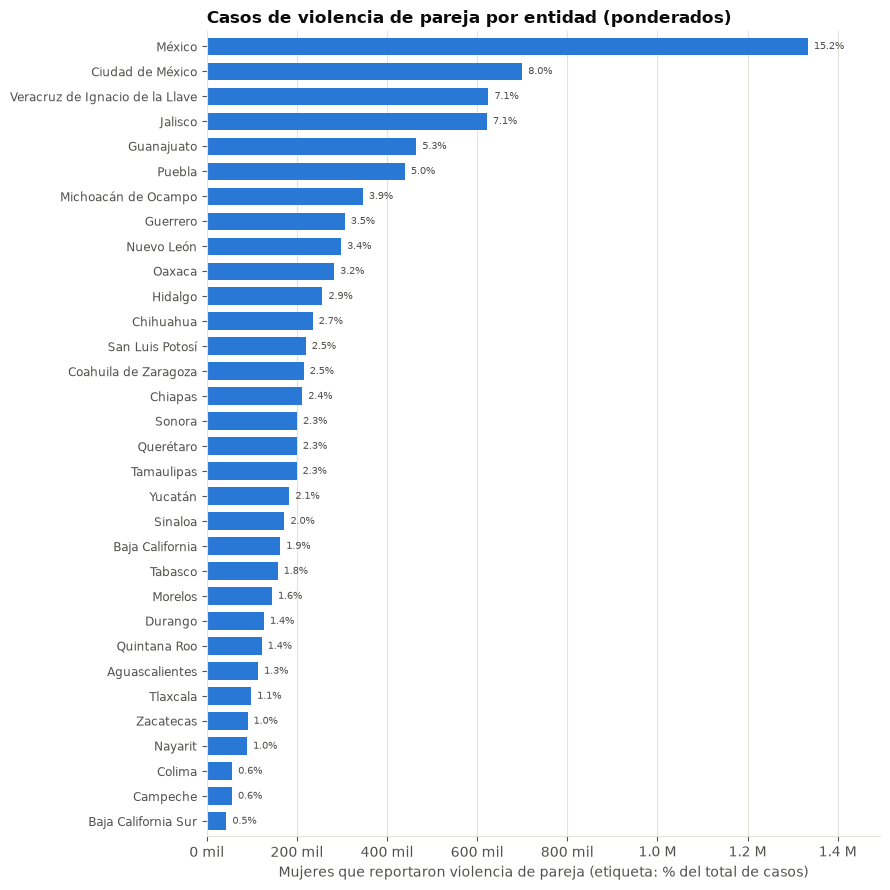

In [8]:
fig = graficas.casos_por_entidad(entidades)
fig.savefig(FIG_DIR / "casos_por_entidad.png", bbox_inches="tight")
plt.show()

**Interpretación.** En números absolutos, el Estado de México (1.33 millones de mujeres, 15.2 % de los casos), Ciudad de México (8.0 %), Veracruz (7.1 %) y Jalisco (7.1 %) acumulan la mayor cantidad de casos; Baja California Sur (0.5 %), Campeche y Colima (0.6 % cada una) los menos. Este orden sigue de cerca el tamaño de la población: el Estado de México también concentra el 14.0 % de las mujeres del país (columna `participacion_poblacion` de la tabla).

Las entidades con menos casos no deben leerse como "entidades con menos violencia": la ENDIREH mide violencia **reportada**, que depende de la disposición a reconocerla y declararla, del contexto cultural y lingüístico, y del error muestral.

### Curva de Lorenz y coeficiente de Gini

In [9]:
gini = tabla_gini(entidades)
gini

medida,descripcion,gini,gini_normalizado
str,str,f64,f64
"""casos""","""Casos de violencia de pareja (…",0.4180,0.4314
"""poblacion""","""Mujeres de 15 años y más (pond…",0.4056,0.4187
"""casos_muestra""","""Casos de violencia en la muest…",0.0961,0.0992


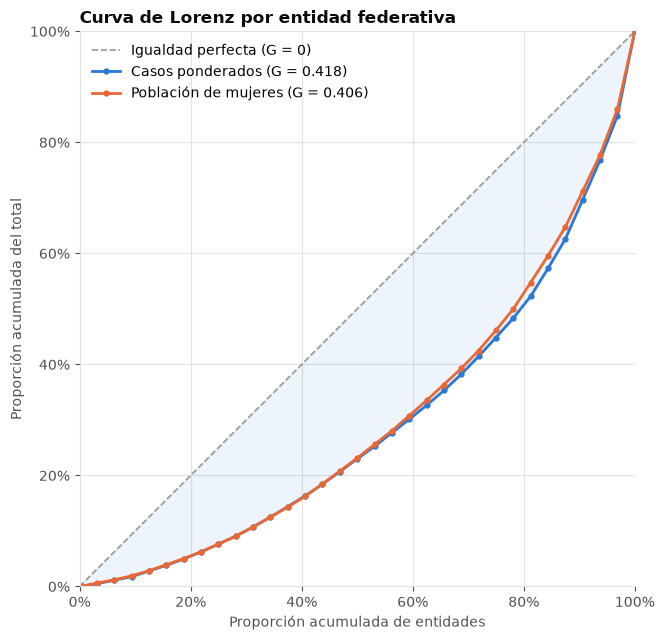

In [10]:
fig = graficas.lorenz({
    "Casos ponderados": entidades["casos"].to_numpy(),
    "Población de mujeres": entidades["poblacion"].to_numpy(),
}, "Curva de Lorenz por entidad federativa")
fig.savefig(FIG_DIR / "lorenz_entidades.png", bbox_inches="tight")
plt.show()

In [11]:
participacion_extremos(entidades['casos'])

{'top_5': np.float64(0.4270134612713947),
 'bottom_5': np.float64(0.03819511192870094),
 'mitad_inferior': np.float64(0.22976071815339022)}

**Interpretación de la curva de Lorenz.** La curva de los casos ponderados se aleja claramente de la diagonal: la mitad de las entidades con menos casos acumula solo el 23 % de ellos, y las 5 entidades con más casos concentran el 42.7 %. El coeficiente de **Gini es 0.418**, una concentración moderada.

Esa concentración, sin embargo, es casi la misma que la de la **población de mujeres** (G = 0.406): las dos curvas casi se superponen. Es decir, los casos se concentran donde vive más gente, no porque haya entidades con una violencia desproporcionada.

Como contraste, el número de casos *sin ponderar* tiene G = 0.096: casi homogéneo porque cada entidad tiene un tamaño de muestra parecido, lo que confirma que no ponderar llevaría a una conclusión equivocada sobre la distribución en la población.